输出的为每一类的置信值$\bf y$

$$\hat{y}=\argmax _i{o_i}$$

对于特殊,要拉开距离
$$o_y-o_i\ge \Delta (y,i)$$

将结果转换为概率
$$\hat{\mathbf{y}} = \mathrm{softmax}(\mathbf{o})\quad \text{其中}\quad \hat{y}_j = \frac{\exp(o_j)}{\sum_k \exp(o_k)}$$

信息熵
$$H[P] = \sum_j - P(j) \log P(j)$$
交叉熵
$$l(\mathbf{y}, \hat{\mathbf{y}}) = - \sum_{j=1}^q y_j \log \hat{y}_j$$
$\bf y$是一个长度$q$为的独热编码向量,其中只有$y_y=1$

所以$l(\mathbf{y}, \hat{\mathbf{y}}) = -\log \hat{y}_y$

$$\begin{split}\begin{aligned}
l(\mathbf{y}, \hat{\mathbf{y}}) &=  - \sum_{j=1}^q y_j \log \frac{\exp(o_j)}{\sum_{k=1}^q \exp(o_k)} \\
&= \sum_{j=1}^q y_j \log \sum_{k=1}^q \exp(o_k) - \sum_{j=1}^q y_j o_j\\
&= \log \sum_{k=1}^q \exp(o_k) - \sum_{j=1}^q y_j o_j.
\end{aligned}\end{split}\\
\partial_{o_j} l(\mathbf{y}, \hat{\mathbf{y}}) = \frac{\exp(o_j)}{\sum_{k=1}^q \exp(o_k)} - y_j = \mathrm{softmax}(\mathbf{o})_j - y_j.$$

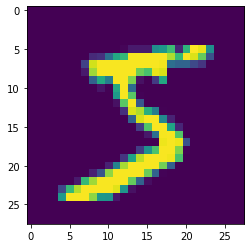

In [16]:
import mine_torch
import torch
import torchvision
import matplotlib.pyplot as plt
from torch.utils import data

# 通过ToTensor实例将图像数据从PIL类型变换成32位浮点数格式，
# 并除以255使得所有像素的数值均在0到1之间
trans = torchvision.transforms.ToTensor()
mnist_train = torchvision.datasets.MNIST(
    root="./data", train=True, transform=trans, download=True)
mnist_test = torchvision.datasets.MNIST(
    root="./data", train=False, transform=trans, download=True)
plt.imshow(mnist_train[0][0][0])
plt.show()

In [17]:
mnist_train[0][0]#第0维是某个example
#第一维为一个元组(data,lable)
#图像为(1,28,28),1代表单通道

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

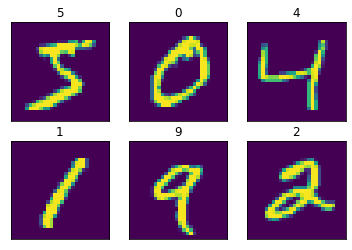

In [18]:
fig,axes=plt.subplots(2,3)
axes=axes.flatten()#一维
for i in range(6):
    ax=axes[i]
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax.imshow(mnist_train[i][0][0])
    ax.set_title(mnist_train[i][1])
plt.show()

In [19]:
batch_size=256
num_input=28*28
num_output=10

train_iter=data.DataLoader(mnist_train,256,True)
test_iter=data.DataLoader(mnist_test,256,True)
W=torch.normal(0,0.01,size=(num_input,num_output),requires_grad=True)
b=torch.zeros(num_output,requires_grad=True)

def softmax(X):
    X_exp=torch.exp(X)
    partition=X_exp.sum(dim=1,keepdim=True)
    return X_exp/partition#广播机制 自动补全

def net(X):#数据(256*784) W(784,10)
    return softmax(torch.matmul(X.reshape((-1,num_input)),W)+b)


In [20]:
y = torch.tensor([0, 2])#直接写索引就行
y_hat = torch.tensor([[0.1, 0.3, 0.6], [0.3, 0.2, 0.5]])
y_hat[[0, 1], y]#[y_hat[0,0],y_hat[1,2]]

tensor([0.1000, 0.5000])

In [21]:
def cross_entropy(y_hat, y):
    return - torch.log(y_hat[range(len(y_hat)), y])

cross_entropy(y_hat, y)

tensor([2.3026, 0.6931])

In [22]:
def my_reshape(X):
    temp=[i[0].reshape(num_input) for i in X]
    train_temp=torch.zeros(len(X),num_input)#形状必须完全一致

    for i in range(len(X)):
        train_temp[i]=temp[i]
    return train_temp

mnist_train_features=my_reshape(mnist_train)
mnist_test_features=my_reshape(mnist_test)
mnist_train_features.shape

torch.Size([60000, 784])

In [23]:

def one_hot_lables(X):#独热化标签
    lable_temp=torch.zeros(len(X),num_output)
    index=[i[1] for i in X]
    for i in range(len(X)):
        lable_temp[i][index[i]]=1
    return lable_temp
one_hot_lables(mnist_train).shape


torch.Size([60000, 10])

In [24]:
net(mnist_train_features)

tensor([[0.0997, 0.0942, 0.1046,  ..., 0.1095, 0.1008, 0.1032],
        [0.1017, 0.0914, 0.0967,  ..., 0.1010, 0.1058, 0.1110],
        [0.0905, 0.1034, 0.1108,  ..., 0.0897, 0.1040, 0.0983],
        ...,
        [0.1001, 0.0956, 0.1065,  ..., 0.0984, 0.1082, 0.1059],
        [0.1046, 0.1016, 0.0971,  ..., 0.1050, 0.1138, 0.0990],
        [0.0892, 0.0948, 0.1065,  ..., 0.0963, 0.0944, 0.1091]],
       grad_fn=<DivBackward0>)

In [25]:
def cal_acc(X,y):
    tot=0
    for i in range(X.shape[0]):
        if(net(mnist_train_features[i]).argmax()==y[i]):
            tot+=1
    return tot/X.shape[0]
#计算准确率

In [26]:
y_train=torch.tensor([i[1] for i in mnist_train])
y_test=torch.tensor([i[1] for i in mnist_test])

cal_acc(mnist_train_features,y_train)

0.13168333333333335

In [27]:

loss=cross_entropy(net(mnist_train_features),y_train).mean()

epochs=100
lr=0.08
acc=[]#准确率
length=len(mnist_train)
for epoch in range(epochs):
    loss=cross_entropy(net(mnist_train_features),y_train).mean()
    loss.backward()
    
    with torch.no_grad():#更新时不用计算梯度
        #非常重要
        W-=(W.grad)*lr
        W.grad.zero_()  
        b-=(b.grad)*lr
        b.grad.zero_()
    if(epoch%10==0):
        acc.append(cal_acc(mnist_train_features,y_train))

            
print(f'epoch {epoch + 1}, loss {loss.item():f}')



epoch 100, loss 0.663025


In [28]:
cal_acc(mnist_train_features,y_train)

0.8546833333333334

In [29]:
for i in range(50):
    print(f'predict:{net(mnist_train_features[i]).argmax()} real:{y_train[i]}')

predict:5 real:5
predict:0 real:0
predict:4 real:4
predict:1 real:1
predict:9 real:9
predict:2 real:2
predict:1 real:1
predict:3 real:3
predict:1 real:1
predict:4 real:4
predict:3 real:3
predict:2 real:5
predict:3 real:3
predict:6 real:6
predict:1 real:1
predict:7 real:7
predict:2 real:2
predict:8 real:8
predict:6 real:6
predict:7 real:9
predict:4 real:4
predict:0 real:0
predict:9 real:9
predict:1 real:1
predict:6 real:1
predict:2 real:2
predict:9 real:4
predict:3 real:3
predict:7 real:2
predict:7 real:7
predict:3 real:3
predict:8 real:8
predict:6 real:6
predict:7 real:9
predict:0 real:0
predict:5 real:5
predict:6 real:6
predict:0 real:0
predict:7 real:7
predict:6 real:6
predict:1 real:1
predict:8 real:8
predict:7 real:7
predict:9 real:9
predict:3 real:3
predict:9 real:9
predict:8 real:8
predict:5 real:5
predict:5 real:9
predict:3 real:3


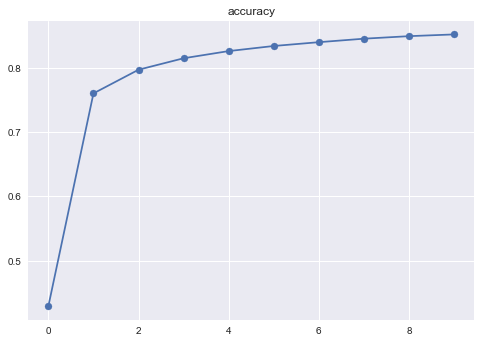

In [34]:
plt.style.use('seaborn')
fig,ax=plt.subplots()
ax.set_title("accuracy")
ax.scatter(range(int(epochs/10)),acc)
ax.plot(range(int(epochs/10)),acc)